In [1]:
# 基础依赖
import os, re, json, struct, warnings
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import rosbag
from geometry_msgs.msg import Point
from scipy.spatial.transform import Rotation as R
from scipy.interpolate import interp1d

warnings.filterwarnings('ignore')

%matplotlib inline
print('✓ 依赖导入完成')


✓ 依赖导入完成


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [ ]:
# 参数配置（可修改）
class Args:
    # 阈值与绘图
    threshold: List[float] = 1.0
    success_time_limit: float = 300.0
    image_width: int = 1280
    image_height: int = 640
    bin_size: int = 20
    r2d2_scale: Tuple[float, float] = (0.0, 0.1)
    ov_scale: Tuple[float, float] = (0.0, 0.6)
    curve_ymax: float = 10.0
    curve_bins: int = 10
    completion_percent: float = 0.9

    # 分组与归一化
    assume_structure: str = 'auto'   # 'map/method' | 'method/map' | 'auto'
    map_regex: Optional[str] = None
    method_regex: Optional[str] = None
    method_keywords: List[str] = [
        'rrt', 'rrtstar', 'rrt_star', 'informedrrt', 'informed_rrt',
        'astar', 'a_star', 'apf', 'teb', 'mpc', 'dwa', 'lqr', 'prm', 'rrtconnect',
        'gbplanner', 'explorer', 'frontier', 'random', 'mcts', 'rl', 'sac', 'ppo',
    ]
    experiments_root: str = 'experiments'
    map_from_filename: bool = True
    map_exp_token: str = '_exp'
    normalize_success_rate: bool = True

    # 输入输出
    inputs: List[str] = [
        'experiments/fuel',
        'experiments/vo_safe',
        'experiments/la_planner',
    ]
    only_maps: Optional[List[str]] = ["test_features"]
    output_dir: str = 'results_batch_notebook'

args = Args()
print('✓ 参数准备完成，输出目录:', os.path.abspath(args.output_dir))


✓ 参数准备完成，输出目录: /home/smoggy/workspace_ros1/r2d2/results_batch_notebook


In [3]:
# 工具函数：误差、配准、插值、热力图、路径推断

def calculate_position_error(gt_pos, est_pos) -> float:
    dx = gt_pos.x - est_pos.x
    dy = gt_pos.y - est_pos.y
    dz = gt_pos.z - est_pos.z
    return float(np.sqrt(dx*dx + dy*dy + dz*dz))


def calculate_orientation_error(gt_quat, est_quat) -> float:
    if hasattr(gt_quat, 'x'):
        gt_quat_array = [gt_quat.x, gt_quat.y, gt_quat.z, gt_quat.w]
    else:
        gt_quat_array = gt_quat
    if hasattr(est_quat, 'x'):
        est_quat_array = [est_quat.x, est_quat.y, est_quat.z, est_quat.w]
    else:
        est_quat_array = est_quat
    r_gt = R.from_quat(gt_quat_array)
    r_est = R.from_quat(est_quat_array)
    r_rel = r_gt * r_est.inv()
    angle = r_rel.magnitude()
    return float(angle)


def compute_rigid_alignment_from_first_odoms(gt_first_msg, vins_first_msg) -> Tuple[R, np.ndarray]:
    gt_initial_pos = gt_first_msg.pose.pose.position
    vins_initial_pos = vins_first_msg.pose.pose.position
    gt_initial_quat = gt_first_msg.pose.pose.orientation
    vins_initial_quat = vins_first_msg.pose.pose.orientation

    r_gt_initial = R.from_quat([gt_initial_quat.x, gt_initial_quat.y, gt_initial_quat.z, gt_initial_quat.w])
    r_vins_initial = R.from_quat([vins_initial_quat.x, vins_initial_quat.y, vins_initial_quat.z, vins_initial_quat.w])
    r_transform = r_gt_initial * r_vins_initial.inv()

    gt_pos_array = np.array([gt_initial_pos.x, gt_initial_pos.y, gt_initial_pos.z], dtype=float)
    vins_pos_array = np.array([vins_initial_pos.x, vins_initial_pos.y, vins_initial_pos.z], dtype=float)
    vins_pos_rotated = r_transform.apply(vins_pos_array)
    translation = gt_pos_array - vins_pos_rotated
    return r_transform, translation


def interpolate_exploration_rate(exploration_times, exploration_rates, target_times):
    if len(exploration_times) < 2:
        return np.full_like(target_times, np.nan)
    interp_func = interp1d(exploration_times, exploration_rates, kind='linear', bounds_error=False, fill_value=np.nan)
    return interp_func(target_times)


def default_edges(image_width: int, image_height: int, bin_size: int):
    return (
        np.linspace(0, image_width, image_width // bin_size + 1),
        np.linspace(0, image_height, image_height // bin_size + 1),
    )


def accumulate_heatmap(sum_array: Optional[np.ndarray], heatmap: np.ndarray, message_count: int, weight=None) -> np.ndarray:
    if sum_array is None:
        return np.array(heatmap, dtype=np.float64) * max(1, int(message_count))
    if weight is None:
        return sum_array + np.array(heatmap, dtype=np.float64) * max(1, int(message_count))
    else:
        return sum_array + np.array(heatmap, dtype=np.float64) * weight


def average_heatmap(sum_array: Optional[np.ndarray], total_messages: int, image_width: int, image_height: int, bin_size: int) -> np.ndarray:
    if sum_array is None or int(total_messages) == 0:
        return np.zeros((image_height // bin_size, image_width // bin_size))
    return sum_array / float(total_messages)


def compute_histogram(u_list, v_list, weights_list, width: int, height: int, bin_size: int, total_count: Optional[int]):
    if len(u_list) == 0:
        heatmap = np.zeros((height // bin_size, width // bin_size))
        x_edges = np.linspace(0, width, width // bin_size + 1)
        y_edges = np.linspace(0, height, height // bin_size + 1)
        return heatmap, x_edges, y_edges
    heatmap, x_edges, y_edges = np.histogram2d(
        u_list, v_list,
        bins=[width // bin_size, height // bin_size],
        range=[[0, width], [0, height]],
        weights=weights_list if (weights_list is not None and len(weights_list) == len(u_list)) else None,
    )
    if total_count is not None and total_count > 0:
        heatmap = heatmap / float(total_count)
    return heatmap, x_edges, y_edges


def tokenize_path(relpath: str) -> List[str]:
    base = os.path.basename(relpath)
    stem = os.path.splitext(base)[0]
    parts = re.split(r"[\\/\._\-]+", relpath.lower()) + re.split(r"[\\/\._\-]+", stem.lower())
    return [p for p in parts if p]


def map_name_from_filename(filename: str, exp_token: str) -> str:
    stem = os.path.splitext(filename)[0]
    idx = stem.lower().find(exp_token.lower())
    if idx > 0:
        return stem[:idx]
    return stem


def infer_map_method(root: str, bag_path: str, assume_structure: str, method_keywords: List[str],
                     map_regex: Optional[str], method_regex: Optional[str], experiments_root: Optional[str] = None,
                     map_from_filename: bool = True, map_exp_token: str = '_exp') -> Tuple[str, str]:
    abs_path = os.path.abspath(bag_path)
    parts = abs_path.replace('\\', '/').split('/')
    method = 'unknown'
    map_name = None

    if experiments_root:
        try:
            if experiments_root in parts:
                idx = parts.index(experiments_root)
                if idx + 1 < len(parts):
                    method = parts[idx + 1]
                if map_from_filename:
                    map_name = map_name_from_filename(os.path.basename(abs_path), map_exp_token)
        except Exception:
            pass

    rel = os.path.relpath(bag_path, root)
    rel_norm = rel.replace('\\', '/')

    if map_name is None:
        if map_regex:
            m = re.search(map_regex, rel_norm)
            if m and m.groups():
                map_name = m.group(1)
        if map_name is None:
            if map_from_filename:
                map_name = map_name_from_filename(os.path.basename(rel_norm), map_exp_token)
            else:
                map_name = os.path.splitext(os.path.basename(rel_norm))[0]

    if method == 'unknown':
        if assume_structure in ('map/method', 'method/map'):
            parts_rel = rel_norm.split('/')
            if len(parts_rel) >= 2:
                if assume_structure == 'map/method':
                    method = parts_rel[1]
                else:
                    method = parts_rel[0]
                    map_name = parts_rel[1]
        else:
            tokens = tokenize_path(rel_norm)
            for t in tokens:
                if t in method_keywords:
                    method = t
                    break
            if method_regex:
                mth = re.search(method_regex, rel_norm)
                if mth and mth.groups():
                    method = mth.group(1)

    return map_name, method

print('✓ 工具函数就绪')


✓ 工具函数就绪


In [15]:
# 读取与预处理：按速度阈值剔除静止阶段 + 对齐并计算误差

def process_rosbag(bag_path: str):
    print(f"Processing ROS bag: {bag_path}")
    exploration_data = []
    gt_odom_data = []
    vins_odom_data = []
    r2d2_pointcloud_data = []
    ov_msckf_pointcloud_data = []
    try:
        with rosbag.Bag(bag_path, 'r') as bag:
            info = bag.get_type_and_topic_info()
            topics = list(info.topics.keys())
            print(f"Available topics: {topics}")
            for topic, msg, t in bag.read_messages():
                timestamp = t.to_sec()
                if topic == '/exploration_rate':
                    rate = msg.data if hasattr(msg, 'data') else float(msg)
                    exploration_data.append([timestamp, rate])
                elif topic == '/kingfisher/ground_truth/odometry':
                    gt_odom_data.append([timestamp, msg])
                elif topic == '/ov_msckf/loop_pose':
                    vins_odom_data.append([timestamp, msg])
                elif topic == '/r2d2/visible_features_uv':
                    r2d2_pointcloud_data.append([timestamp, msg])
                elif topic == '/ov_msckf/loop_feats':
                    ov_msckf_pointcloud_data.append([timestamp, msg])
    except Exception as e:
        print(f"Error reading bag file: {e}")
        return None, None, None, None, None
    print(f"Found {len(exploration_data)} exploration rate messages")
    print(f"Found {len(gt_odom_data)} ground truth odometry messages")
    print(f"Found {len(vins_odom_data)} VINS odometry messages")
    print(f"Found {len(r2d2_pointcloud_data)} R2D2 point cloud messages")
    print(f"Found {len(ov_msckf_pointcloud_data)} OV-MSCKF loop feature messages")
    return exploration_data, gt_odom_data, vins_odom_data, r2d2_pointcloud_data, ov_msckf_pointcloud_data


def synchronize_and_calculate_errors(exploration_data, gt_odom_data, vins_odom_data,
                                     speed_threshold: float = 0.1):
    if not all([exploration_data, gt_odom_data, vins_odom_data]):
        return (None,) * 12

    exploration_times = np.array([d[0] for d in exploration_data])
    exploration_rates = np.array([d[1] for d in exploration_data])
    gt_times = np.array([d[0] for d in gt_odom_data])
    vins_times = np.array([d[0] for d in vins_odom_data])

    start_time = max(exploration_times.min(), gt_times.min(), vins_times.min())
    end_time = min(exploration_times.max(), gt_times.max(), vins_times.max())

    # 速度阈值推断有效时间窗（剔除前端静止）
    gt_positions = []
    gt_pos_times = []
    for timestamp, msg in gt_odom_data:
        if start_time <= timestamp <= end_time:
            gt_positions.append([msg.pose.pose.position.x, msg.pose.pose.position.y, msg.pose.pose.position.z])
            gt_pos_times.append(timestamp)
    if len(gt_positions) >= 2:
        t = np.asarray(gt_pos_times, dtype=np.float64)
        p = np.asarray(gt_positions, dtype=np.float64)
        dp = np.diff(p, axis=0)
        dt = np.diff(t)
        dt[dt == 0] = np.nan
        speed = np.linalg.norm(dp, axis=1) / dt
        t_mid = (t[1:] + t[:-1]) / 2.0
        idxs = np.where(speed >= speed_threshold)[0]
        if idxs.size > 0:
            speed_start_time = t_mid[idxs[0]]
            speed_end_time = t_mid[idxs[-1]]
        else:
            speed_start_time = start_time
            speed_end_time = end_time
        start_time = max(start_time, speed_start_time)
        # end_time = min(end_time, speed_end_time)
    else:
        pass

    exp_mask = (exploration_times >= start_time) & (exploration_times <= end_time)
    gt_mask = (gt_times >= start_time) & (gt_times <= end_time)
    vins_mask = (vins_times >= start_time) & (vins_times <= end_time)

    exploration_times_filtered = exploration_times[exp_mask]
    exploration_rates_filtered = exploration_rates[exp_mask]

    first_gt_time = gt_times[gt_mask][0] if np.any(gt_mask) else None
    first_vins_time = vins_times[vins_mask][0] if np.any(vins_mask) else None
    if first_gt_time is None or first_vins_time is None:
        return (None,) * 12

    first_common_time = max(first_gt_time, first_vins_time)
    gt_first_idx = int(np.argmin(np.abs(gt_times - first_common_time)))
    vins_first_idx = int(np.argmin(np.abs(vins_times - first_common_time)))

    gt_first_msg = gt_odom_data[gt_first_idx][1]
    vins_first_msg = vins_odom_data[vins_first_idx][1]

    r_transform, translation = compute_rigid_alignment_from_first_odoms(gt_first_msg, vins_first_msg)

    error_times, position_errors, orientation_errors = [], [], []
    gt_trajectory_times, gt_trajectory_x, gt_trajectory_y, gt_trajectory_z = [], [], [], []
    vins_trajectory_times, vins_trajectory_x, vins_trajectory_y, vins_trajectory_z = [], [], [], []

    for vins_time, vins_msg in vins_odom_data:
        if vins_time < first_common_time or vins_time > end_time:
            continue
        gt_diffs = np.abs(gt_times - vins_time)
        gt_idx = int(np.argmin(gt_diffs))
        if gt_diffs[gt_idx] > 0.1:
            continue
        gt_msg = gt_odom_data[gt_idx][1]

        vins_pos_array = np.array([
            vins_msg.pose.pose.position.x,
            vins_msg.pose.pose.position.y,
            vins_msg.pose.pose.position.z,
        ])
        vins_pos_rotated = r_transform.apply(vins_pos_array)
        vins_pos_transformed = vins_pos_rotated + translation

        aligned_vins_pos = Point()
        aligned_vins_pos.x = float(vins_pos_transformed[0])
        aligned_vins_pos.y = float(vins_pos_transformed[1])
        aligned_vins_pos.z = float(vins_pos_transformed[2])

        r_vins_current = R.from_quat([
            vins_msg.pose.pose.orientation.x,
            vins_msg.pose.pose.orientation.y,
            vins_msg.pose.pose.orientation.z,
            vins_msg.pose.pose.orientation.w,
        ])
        r_vins_aligned = r_transform * r_vins_current

        pos_error = calculate_position_error(gt_msg.pose.pose.position, aligned_vins_pos)
        orient_error = calculate_orientation_error(
            gt_msg.pose.pose.orientation,
            r_vins_aligned.as_quat(),
        )
        error_times.append(vins_time)
        position_errors.append(pos_error)
        orientation_errors.append(orient_error)

        gt_trajectory_times.append(gt_times[gt_idx])
        gt_trajectory_x.append(gt_msg.pose.pose.position.x)
        gt_trajectory_y.append(gt_msg.pose.pose.position.y)
        gt_trajectory_z.append(gt_msg.pose.pose.position.z)

        vins_trajectory_times.append(vins_time)
        vins_trajectory_x.append(aligned_vins_pos.x)
        vins_trajectory_y.append(aligned_vins_pos.y)
        vins_trajectory_z.append(aligned_vins_pos.z)

    error_times = np.array(error_times)
    position_errors = np.array(position_errors)
    orientation_errors = np.array(orientation_errors)

    gt_trajectory_times = np.array(gt_trajectory_times)
    gt_trajectory_x = np.array(gt_trajectory_x)
    gt_trajectory_y = np.array(gt_trajectory_y)
    gt_trajectory_z = np.array(gt_trajectory_z)

    vins_trajectory_times = np.array(vins_trajectory_times)
    vins_trajectory_x = np.array(vins_trajectory_x)
    vins_trajectory_y = np.array(vins_trajectory_y)
    vins_trajectory_z = np.array(vins_trajectory_z)

    return (
        exploration_times_filtered, exploration_rates_filtered,
        error_times, position_errors, orientation_errors,
        gt_trajectory_times, gt_trajectory_x, gt_trajectory_y, gt_trajectory_z,
        vins_trajectory_times, vins_trajectory_x, vins_trajectory_y, vins_trajectory_z
    )


def process_pointcloud_data(r2d2_pointcloud_data, ov_msckf_pointcloud_data, start_time=0, image_width: int = 1280, image_height: int = 640, return_times: bool = False):
    r2d2_u_coords, r2d2_v_coords, r2d2_intensities = [], [], []
    ov_msckf_u_coords, ov_msckf_v_coords = [], []
    r2d2_weight_per_msg, ov_count_per_msg = [], []
    # 每条消息的时间戳与计数/密度
    r2d2_msg_times, ov_msg_times = [], []
    r2d2_count_per_msg = []
    ov_count_per_msg_raw = []

    for ts, msg in r2d2_pointcloud_data:
        if msg.header.stamp.to_sec() < start_time:
            continue
        try:
            msg_sum = 0.0
            msg_count = 0
            if hasattr(msg, 'fields'):
                u_field = v_field = intensity_field = None
                for field in msg.fields:
                    if field.name == 'u':
                        u_field = field
                    elif field.name == 'v':
                        v_field = field
                    elif field.name == 'intensity':
                        intensity_field = field
                if u_field is not None and v_field is not None:
                    u_offset = u_field.offset
                    v_offset = v_field.offset
                    intensity_offset = intensity_field.offset if intensity_field else None
                    point_step = msg.point_step
                    data = np.frombuffer(msg.data, dtype=np.uint8)
                    for i in range(msg.width * msg.height):
                        start_idx = i * point_step
                        u = np.frombuffer(data[start_idx + u_offset:start_idx + u_offset + 4], dtype=np.float32)[0]
                        v = np.frombuffer(data[start_idx + v_offset:start_idx + v_offset + 4], dtype=np.float32)[0]
                        intensity = 1.0
                        if intensity_field is not None:
                            intensity = np.frombuffer(data[start_idx + intensity_offset:start_idx + intensity_offset + 4], dtype=np.float32)[0]
                        r2d2_u_coords.append(float(u))
                        r2d2_v_coords.append(float(v))
                        r2d2_intensities.append(float(intensity))
                        msg_sum += float(intensity)
                        msg_count += 1
            else:
                if hasattr(msg, 'channels') and len(msg.channels) > 0:
                    u_channel = v_channel = intensity_channel = None
                    for channel in msg.channels:
                        if channel.name == 'u':
                            u_channel = channel
                        elif channel.name == 'v':
                            v_channel = channel
                        elif channel.name == 'intensity':
                            intensity_channel = channel
                    if u_channel is not None and v_channel is not None:
                        for i in range(len(msg.points)):
                            u = u_channel.values[i]
                            v = v_channel.values[i]
                            intensity = intensity_channel.values[i] if intensity_channel else 1.0
                            r2d2_u_coords.append(float(u))
                            r2d2_v_coords.append(float(v))
                            r2d2_intensities.append(float(intensity))
                            msg_sum += float(intensity)
                            msg_count += 1
        except Exception as e:
            print(f"Error processing R2D2 point cloud message: {e}")
            msg_sum = msg_sum if 'msg_sum' in locals() else 0.0
            msg_count = msg_count if 'msg_count' in locals() else 0
        if msg_count > 0:
            r2d2_weight_per_msg.append(msg_sum)
            r2d2_count_per_msg.append(int(msg_count))
            r2d2_msg_times.append(float(ts) - float(start_time))

    for ts, msg in ov_msckf_pointcloud_data:
        if msg.header.stamp.to_sec() < start_time:
            continue
        try:
            msg_count = 0
            if hasattr(msg, 'fields'):
                u_field = v_field = None
                for field in msg.fields:
                    if field.name == 'u':
                        u_field = field
                    elif field.name == 'v':
                        v_field = field
                if u_field is not None and v_field is not None:
                    u_offset = u_field.offset
                    v_offset = v_field.offset
                    point_step = msg.point_step
                    data = np.frombuffer(msg.data, dtype=np.uint8)
                    for i in range(msg.width * msg.height):
                        start_idx = i * point_step
                        u = np.frombuffer(data[start_idx + u_offset:start_idx + u_offset + 4], dtype=np.float32)[0]
                        v = np.frombuffer(data[start_idx + v_offset:start_idx + v_offset + 4], dtype=np.float32)[0]
                        ov_msckf_u_coords.append(float(u))
                        ov_msckf_v_coords.append(float(v))
                        msg_count += 1
            else:
                if hasattr(msg, 'channels') and len(msg.channels) > 0:
                    for channel in msg.channels:
                        if len(channel.values) >= 5:
                            u = channel.values[2]
                            v = channel.values[3]
                            ov_msckf_u_coords.append(float(u))
                            ov_msckf_v_coords.append(float(v))
                            msg_count += 1
        except Exception as e:
            print(f"Error processing OV-MSCKF point cloud message: {e}")
            msg_count = msg_count if 'msg_count' in locals() else 0
        if msg_count > 0:
            ov_count_per_msg.append(msg_count)
            ov_count_per_msg_raw.append(int(msg_count))
            ov_msg_times.append(float(ts) - float(start_time))

    print(f"Extracted {len(r2d2_u_coords)} R2D2 feature points")
    print(f"Extracted {len(ov_msckf_u_coords)} OV-MSCKF loop feature points")

    if not return_times:
        return (
            r2d2_u_coords, r2d2_v_coords, r2d2_intensities,
            ov_msckf_u_coords, ov_msckf_v_coords,
            r2d2_weight_per_msg, ov_count_per_msg,
        )

    img_area = max(1, int(image_width) * int(image_height))
    r2d2_density_per_msg = [float(c) / float(img_area) for c in r2d2_count_per_msg]
    ov_density_per_msg = [float(c) / float(img_area) for c in ov_count_per_msg_raw]

    return (
        r2d2_u_coords, r2d2_v_coords, r2d2_intensities,
        ov_msckf_u_coords, ov_msckf_v_coords,
        r2d2_weight_per_msg, ov_count_per_msg,
        np.asarray(r2d2_msg_times, dtype=float), np.asarray(r2d2_density_per_msg, dtype=float),
        np.asarray(ov_msg_times, dtype=float), np.asarray(ov_density_per_msg, dtype=float),
    )

print('✓ 读取与预处理函数就绪（已包含静止段剔除）')


✓ 读取与预处理函数就绪（已包含静止段剔除）


In [5]:
# 从原始数据执行后处理（与读取解耦）

def postprocess_single_bag_from_raw(raw_data: tuple, args):
    (
        exploration_data, gt_odom_data, vins_odom_data,
        r2d2_pointcloud_data, ov_msckf_pointcloud_data,
    ) = raw_data

    if not all([exploration_data, gt_odom_data, vins_odom_data]):
        return None

    (
        exploration_times, exploration_rates, error_times, position_errors, orientation_errors,
        gt_trajectory_times, gt_x, gt_y, gt_z,
        vins_trajectory_times, vins_x, vins_y, vins_z
    ) = synchronize_and_calculate_errors(exploration_data, gt_odom_data, vins_odom_data)

    if exploration_times is None:
        return None

    total_time = float(exploration_times[-1] - exploration_times[0]) if len(exploration_times) > 1 else 0.0
    exp_rate_on_error_t = interpolate_exploration_rate(exploration_times, exploration_rates, error_times)

    failure_idx = None
    failure_time = None
    if len(position_errors) > 0:
        mask = position_errors >= args.threshold
        if np.any(mask):
            failure_idx = int(np.argmax(mask))
            failure_time = float(error_times[failure_idx])

    if failure_idx is not None:
        success_exploration_rate = float(exp_rate_on_error_t[failure_idx]) if not np.isnan(exp_rate_on_error_t[failure_idx]) else float('nan')
    else:
        success_exploration_rate = float(exploration_rates[-1]) if len(exploration_rates) > 0 else float('nan')

    success_run = (failure_idx is None) and (total_time < args.success_time_limit)

    # 启用带时间戳与密度返回（便于后续绘制密度时间序列）
    pcd = process_pointcloud_data(
        r2d2_pointcloud_data, ov_msckf_pointcloud_data,
        start_time=exploration_times[0], image_width=args.image_width, image_height=args.image_height, return_times=True
    )

    (
        r2d2_u, r2d2_v, r2d2_intensity,
        ov_u, ov_v,
        r2d2_weight_per_msg, ov_count_per_msg,
        r2d2_msg_times, r2d2_density_per_msg,
        ov_msg_times, ov_density_per_msg,
    ) = pcd

    r2d2_msg_count = int(len(r2d2_weight_per_msg))
    ov_msg_count = int(len(ov_count_per_msg))

    r2d2_heat, r2d2_xe, r2d2_ye = compute_histogram(
        r2d2_u, r2d2_v, r2d2_intensity, args.image_width, args.image_height, args.bin_size, r2d2_msg_count
    )
    ov_heat, ov_xe, ov_ye = compute_histogram(
        ov_u, ov_v, None, args.image_width, args.image_height, args.bin_size, ov_msg_count
    )

    ov_mean_per_msg = float(np.mean(ov_count_per_msg)) if len(ov_count_per_msg) > 0 else float('nan')
    r2d2_weight_mean_per_msg = float(np.mean(r2d2_weight_per_msg)) if len(r2d2_weight_per_msg) > 0 else float('nan')

    return {
        'total_time': total_time,
        'failure_time': failure_time,
        'success_exploration_rate': success_exploration_rate,
        'success_exploration_rate_raw': success_exploration_rate,
        'success_run': success_run,
        'r2d2_heat': r2d2_heat,
        'r2d2_edges': (r2d2_xe, r2d2_ye),
        'ov_heat': ov_heat,
        'ov_edges': (ov_xe, ov_ye),
        'ov_mean_per_msg': ov_mean_per_msg,
        'r2d2_weight_mean_per_msg': r2d2_weight_mean_per_msg,
        'r2d2_msg_count': r2d2_msg_count,
        'ov_msg_count': ov_msg_count,
        'curve_x': exp_rate_on_error_t,
        'curve_y': position_errors,
        'raw_exploration_times': exploration_times,
        'raw_exploration_rates': exploration_rates,
        'raw_exp_rate_on_error_t': exp_rate_on_error_t,
        'last_exploration_rate': float(exploration_rates[-1]) if len(exploration_rates) > 0 else float('nan'),
        # 新增：密度时间序列
        'r2d2_msg_times': r2d2_msg_times,
        'r2d2_density_per_msg': r2d2_density_per_msg,
        'ov_msg_times': ov_msg_times,
        'ov_density_per_msg': ov_density_per_msg,
    }

print('✓ 后处理函数就绪（与读取解耦）')



✓ 后处理函数就绪（与读取解耦）


In [6]:
# 单包处理：复用上面的函数，返回与脚本一致的结构

def process_single_bag(bag_path: str, args):
    (
        exploration_data, gt_odom_data, vins_odom_data,
        r2d2_pointcloud_data, ov_msckf_pointcloud_data,
    ) = process_rosbag(bag_path)
    if not all([exploration_data, gt_odom_data, vins_odom_data]):
        return None

    result = synchronize_and_calculate_errors(exploration_data, gt_odom_data, vins_odom_data)
    if result[0] is None:
        return None

    (
        exploration_times, exploration_rates, error_times, position_errors, orientation_errors,
        gt_trajectory_times, gt_x, gt_y, gt_z,
        vins_trajectory_times, vins_x, vins_y, vins_z
    ) = result

    total_time = float(exploration_times[-1] - exploration_times[0]) if len(exploration_times) > 1 else 0.0
    exp_rate_on_error_t = interpolate_exploration_rate(exploration_times, exploration_rates, error_times)

    failure_idx = None
    failure_time = None
    if len(position_errors) > 0:
        mask = position_errors >= args.threshold
        if np.any(mask):
            failure_idx = int(np.argmax(mask))
            failure_time = float(error_times[failure_idx])

    if failure_idx is not None:
        success_exploration_rate = float(exp_rate_on_error_t[failure_idx]) if not np.isnan(exp_rate_on_error_t[failure_idx]) else float('nan')
    else:
        success_exploration_rate = float(exploration_rates[-1]) if len(exploration_rates) > 0 else float('nan')

    success_run = (failure_idx is None) and (total_time < args.success_time_limit)

    r2d2_u, r2d2_v, r2d2_intensity, ov_u, ov_v, r2d2_weight_per_msg, ov_count_per_msg = process_pointcloud_data(
        r2d2_pointcloud_data, ov_msckf_pointcloud_data, exploration_times[0]
    )
    r2d2_msg_count = int(len(r2d2_weight_per_msg))
    ov_msg_count = int(len(ov_count_per_msg))

    r2d2_heat, r2d2_xe, r2d2_ye = compute_histogram(
        r2d2_u, r2d2_v, r2d2_intensity, args.image_width, args.image_height, args.bin_size, r2d2_msg_count
    )
    ov_heat, ov_xe, ov_ye = compute_histogram(
        ov_u, ov_v, None, args.image_width, args.image_height, args.bin_size, ov_msg_count
    )

    ov_mean_per_msg = float(np.mean(ov_count_per_msg)) if len(ov_count_per_msg) > 0 else float('nan')
    r2d2_weight_mean_per_msg = float(np.mean(r2d2_weight_per_msg)) if len(r2d2_weight_per_msg) > 0 else float('nan')

    return {
        'total_time': total_time,
        'failure_time': failure_time,
        'success_exploration_rate': success_exploration_rate,
        'success_exploration_rate_raw': success_exploration_rate,
        'success_run': success_run,
        'r2d2_heat': r2d2_heat,
        'r2d2_edges': (r2d2_xe, r2d2_ye),
        'ov_heat': ov_heat,
        'ov_edges': (ov_xe, ov_ye),
        'ov_mean_per_msg': ov_mean_per_msg,
        'r2d2_weight_mean_per_msg': r2d2_weight_mean_per_msg,
        'r2d2_msg_count': r2d2_msg_count,
        'ov_msg_count': ov_msg_count,
        'curve_x': exp_rate_on_error_t,
        'curve_y': position_errors,
        'raw_exploration_times': exploration_times,
        'raw_exploration_rates': exploration_rates,
        'raw_exp_rate_on_error_t': exp_rate_on_error_t,
        'last_exploration_rate': float(exploration_rates[-1]) if len(exploration_rates) > 0 else float('nan'),
    }

print('✓ 单包处理函数就绪')


✓ 单包处理函数就绪


In [7]:
# Pass 1 & 2：发现bag、分组、计算 success_ref 并汇总

def discover_bag_files(paths: List[str], recursive: bool = True) -> List[str]:
    bags = []
    for p in paths:
        if os.path.isfile(p) and p.endswith('.bag'):
            bags.append(os.path.abspath(p))
        elif os.path.isdir(p):
            if recursive:
                for root, _, files in os.walk(p):
                    for f in files:
                        if f.endswith('.bag'):
                            bags.append(os.path.join(root, f))
            else:
                for f in os.listdir(p):
                    if f.endswith('.bag'):
                        bags.append(os.path.join(p, f))
    return sorted(list(set(bags)))


def build_success_ref_map(group_results: Dict[Tuple[str, str], List[dict]],
                          normalize_by_method: Optional[Dict[str, str]] = None) -> Dict[Tuple[str, str], float]:
    success_ref_map: Dict[Tuple[str, str], float] = {}
    for key, results in group_results.items():
        success_candidates: List[float] = []
        fallback_max_last_rate = 0.0
        for res in results:
            last_rate = float(res.get('last_exploration_rate', float('nan')))
            if np.isfinite(last_rate) and last_rate > fallback_max_last_rate:
                fallback_max_last_rate = last_rate
            if res.get('success_run', False) and np.isfinite(last_rate) and last_rate > 0:
                success_candidates.append(last_rate)
        if success_candidates:
            success_ref = float(max(success_candidates))
        else:
            success_ref = float(fallback_max_last_rate) if np.isfinite(fallback_max_last_rate) and fallback_max_last_rate > 0 else 1.0
        success_ref_map[key] = success_ref
    if normalize_by_method:
        map_to_methods: Dict[str, Dict[str, float]] = defaultdict(dict)
        for (map_name, method), value in success_ref_map.items():
            map_to_methods[map_name][method] = value
        for map_name in map_to_methods.keys():
            for target_method, ref_method in normalize_by_method.items():
                ref_value = map_to_methods[map_name].get(ref_method)
                if ref_value is not None:
                    success_ref_map[(map_name, target_method)] = ref_value
    return success_ref_map

# 执行批处理（Pass 1：仅读取并缓存原始数据）
bag_files = discover_bag_files(args.inputs, recursive=True)
print('Found', len(bag_files), 'bag files')
if len(bag_files) == 0:
    raise SystemExit('No .bag files found under inputs')

# 计算 overall_root 用于相对路径推断
if any(os.path.isdir(p) for p in args.inputs):
    dir_inputs = [os.path.abspath(p) for p in args.inputs if os.path.isdir(p)]
    overall_root = os.path.commonpath(dir_inputs)
else:
    overall_root = os.path.commonpath([os.path.dirname(b) for b in bag_files])

# 分组 (map, method)
groups: Dict[Tuple[str, str], List[str]] = defaultdict(list)
only_maps_set = set(args.only_maps) if args.only_maps else None

for bag in bag_files:
    map_name, method = infer_map_method(
        overall_root, bag, args.assume_structure, [k.lower() for k in args.method_keywords],
        args.map_regex, args.method_regex, experiments_root=args.experiments_root,
        map_from_filename=args.map_from_filename, map_exp_token=args.map_exp_token,
    )
    if only_maps_set is not None and map_name not in only_maps_set:
        continue
    groups[(map_name, method)].append(bag)

# Pass 1：仅读取原始数据
dict_raw_group_data: Dict[Tuple[str, str], List[tuple]] = defaultdict(list)
print('\n-- Pass 1: 读取并缓存原始 bag 数据 --')
for (map_name, method), bags in sorted(groups.items()):
    print(f"\n=== Group: map={map_name}, method={method}, count={len(bags)} ===")
    for bag in bags:
        print(f"-- Reading raw: {bag}")
        raw = process_rosbag(bag)
        if raw[0] is None:
            print('Skip due to reading failure')
            continue
        dict_raw_group_data[(map_name, method)].append(raw)

# Pass 1.5：后处理参考仅在 Pass 2 后构造，因此此处先占位（由 Pass 2 动态计算）
print('✓ 原始数据缓存完成，可重复调整参数进行后处理')


Found 83 bag files

-- Pass 1: 读取并缓存原始 bag 数据 --

=== Group: map=construction, method=fuel, count=9 ===
-- Reading raw: experiments/fuel/construction_exp_10_161501.bag
Processing ROS bag: experiments/fuel/construction_exp_10_161501.bag
Available topics: ['/exploration_rate', '/kingfisher/ground_truth/odometry', '/ov_msckf/loop_feats', '/ov_msckf/loop_pose', '/r2d2/visible_features_uv', '/sdf_map/occupancy_all', '/sdf_map/occupancy_local']
Found 1850 exploration rate messages
Found 59475 ground truth odometry messages
Found 925 VINS odometry messages
Found 39 R2D2 point cloud messages
Found 925 OV-MSCKF loop feature messages
-- Reading raw: experiments/fuel/construction_exp_1_155530.bag
Processing ROS bag: experiments/fuel/construction_exp_1_155530.bag
Available topics: ['/exploration_rate', '/kingfisher/ground_truth/odometry', '/ov_msckf/loop_feats', '/ov_msckf/loop_pose', '/r2d2/visible_features_uv', '/sdf_map/occupancy_all', '/sdf_map/occupancy_local']
Found 2051 exploration rate mes

In [8]:
# Pass 2：全局归一化与统计（从原始缓存进行后处理，可反复调整参数）
# class Args:
#     # 阈值与绘图
#     threshold: List[float] = 3.0
#     success_time_limit: float = 300.0
#     image_width: int = 1280
#     image_height: int = 640
#     bin_size: int = 20
#     r2d2_scale: Tuple[float, float] = (0.0, 0.1)
#     ov_scale: Tuple[float, float] = (0.0, 0.6)
#     curve_ymax: float = 10.0
#     curve_bins: int = 10
#     completion_percent: float = 0.9

#     # 分组与归一化
#     assume_structure: str = 'auto'   # 'map/method' | 'method/map' | 'auto'
#     map_regex: Optional[str] = None
#     method_regex: Optional[str] = None
#     method_keywords: List[str] = [
#         'rrt', 'rrtstar', 'rrt_star', 'informedrrt', 'informed_rrt',
#         'astar', 'a_star', 'apf', 'teb', 'mpc', 'dwa', 'lqr', 'prm', 'rrtconnect',
#         'gbplanner', 'explorer', 'frontier', 'random', 'mcts', 'rl', 'sac', 'ppo',
#     ]
#     experiments_root: str = 'experiments'
#     map_from_filename: bool = True
#     map_exp_token: str = '_exp'
#     normalize_success_rate: bool = True

#     # 输入输出
#     inputs: List[str] = [
#         'experiments/fuel',
#         'experiments/vo_safe',
#         'experiments/la_planner',
#     ]
#     only_maps: Optional[List[str]] = ["construction"]
#     output_dir: str = 'results_batch_notebook'

args.threshold = 1.0
args.completion_percent = 0.9



# 聚合容器
heatmaps_r2d2 = defaultdict(dict)
heatmaps_ov = defaultdict(dict)
curve_points = defaultdict(lambda: defaultdict(list))
# 新增：特征密度时间序列按组缓存
series_density_r2d2 = defaultdict(lambda: defaultdict(list))
series_density_ov = defaultdict(lambda: defaultdict(list))

rows_success_rate = []
rows_success_time = []
rows_feat_per_ts = []

print('\n-- Pass 2: 全局归一化与统计 --')
proc_group_results: Dict[Tuple[str, str], List[dict]] = defaultdict(list)
for (map_name, method), raw_list in sorted(dict_raw_group_data.items()):
    results = []
    for raw in raw_list:
        res = postprocess_single_bag_from_raw(raw, args)
        if res is None:
            continue
        results.append(res)
    proc_group_results[(map_name, method)] = results

# 构建 success_ref_map（可按方法归一化）
success_ref_map = build_success_ref_map(proc_group_results, normalize_by_method={'la_planner': 'fuel'})

for (map_name, method), results in sorted(proc_group_results.items()):
    success_ref = success_ref_map[(map_name, method)]
    success_rates = []
    success_times = []
    ov_means = []
    r2d2_weight_means = []

    sum_r2d2 = None
    sum_ov = None
    total_r2d2_msgs = 0
    total_ov_msgs = 0
    r2d2_edges = None
    ov_edges = None

    method_curve_pairs = []

    # 新增：收集密度时间序列（用于后续绘图：均值+方差带+柱状对比）
    r2d2_all_t, r2d2_all_d = [], []
    ov_all_t, ov_all_d = [], []

    for res in results:
        if 'ov_mean_per_msg' in res and not np.isnan(res['ov_mean_per_msg']):
            ov_means.append(res['ov_mean_per_msg'])
        if 'r2d2_weight_mean_per_msg' in res and not np.isnan(res['r2d2_weight_mean_per_msg']):
            r2d2_weight_means.append(res['r2d2_weight_mean_per_msg'])

        sum_r2d2 = accumulate_heatmap(sum_r2d2, res['r2d2_heat'], res.get('r2d2_msg_count', 0))
        sum_ov = accumulate_heatmap(sum_ov, res['ov_heat'], res.get('ov_msg_count', 0))
        if r2d2_edges is None:
            r2d2_edges = res['r2d2_edges']
        if ov_edges is None:
            ov_edges = res['ov_edges']
        total_r2d2_msgs += int(res.get('r2d2_msg_count', 0))
        total_ov_msgs += int(res.get('ov_msg_count', 0))

        raw_success_rate = float(res.get('success_exploration_rate_raw', np.nan))
        if np.isfinite(raw_success_rate):
            rate_val = raw_success_rate
            if args.normalize_success_rate:
                rate_val = float(np.clip(rate_val / success_ref, 0.0, 1.0))
            success_rates.append(rate_val)

        t_arr = np.asarray(res.get('raw_exploration_times', []), dtype=float)
        r_arr = np.asarray(res.get('raw_exploration_rates', []), dtype=float)
        if t_arr.size > 0 and r_arr.size > 0 and np.isfinite(success_ref) and success_ref > 0:
            cutoff = float(success_ref * float(args.completion_percent))
            idxs = np.where(r_arr >= cutoff)[0]
            if idxs.size > 0:
                t_comp = float(t_arr[int(idxs[0])] - t_arr[0])
                if np.isfinite(t_comp) and t_comp >= 0:
                    success_times.append(t_comp)

        if method != 'la_planner':
            if 'raw_exp_rate_on_error_t' in res and 'curve_y' in res:
                try:
                    norm_rate_arr = np.clip(np.asarray(res['raw_exp_rate_on_error_t'], dtype=float) / success_ref, 0.0, 1.0)
                except Exception:
                    norm_rate_arr = np.asarray(res['curve_x'])
                pos_err_arr = np.asarray(res['curve_y'])
                fallback_val = float(np.clip(raw_success_rate / success_ref, 0.0, 1.0)) if np.isfinite(raw_success_rate) else float('nan')
                if norm_rate_arr is not None and norm_rate_arr.size > 0 and pos_err_arr.size > 0:
                    method_curve_pairs.append((pos_err_arr, norm_rate_arr, fallback_val))

        # 密度时间序列
        if 'r2d2_msg_times' in res and 'r2d2_density_per_msg' in res:
            if len(res['r2d2_msg_times']) > 0:
                r2d2_all_t.append(np.asarray(res['r2d2_msg_times'], dtype=float))
                r2d2_all_d.append(np.asarray(res['r2d2_density_per_msg'], dtype=float))
        if 'ov_msg_times' in res and 'ov_density_per_msg' in res:
            if len(res['ov_msg_times']) > 0:
                ov_all_t.append(np.asarray(res['ov_msg_times'], dtype=float))
                ov_all_d.append(np.asarray(res['ov_density_per_msg'], dtype=float))

    avg_r2d2 = average_heatmap(sum_r2d2, total_r2d2_msgs, args.image_width, args.image_height, args.bin_size)
    avg_ov = average_heatmap(sum_ov, total_ov_msgs, args.image_width, args.image_height, args.bin_size)
    if r2d2_edges is None:
        r2d2_edges = default_edges(args.image_width, args.image_height, args.bin_size)
    if ov_edges is None:
        ov_edges = default_edges(args.image_width, args.image_height, args.bin_size)

    heatmaps_r2d2[map_name][method] = (avg_r2d2, r2d2_edges[0], r2d2_edges[1])
    heatmaps_ov[map_name][method] = (avg_ov, ov_edges[0], ov_edges[1])

    if method_curve_pairs:
        curve_points[map_name][method] = method_curve_pairs

    if success_rates:
        rows_success_rate.append([map_name, method, len(success_rates), float(np.mean(success_rates)), float(np.std(success_rates))])
    else:
        rows_success_rate.append([map_name, method, 0, float('nan'), float('nan')])

    if success_times:
        rows_success_time.append([map_name, method, len(success_times), float(np.mean(success_times)), float(np.std(success_times))])
    else:
        rows_success_time.append([map_name, method, 0, float('nan'), float('nan')])

    if ov_means or r2d2_weight_means:
        n_feat = max(len(ov_means), len(r2d2_weight_means))
        rows_feat_per_ts.append([
            map_name, method,
            n_feat,
            float(np.mean(ov_means)) if ov_means else float('nan'),
            float(np.std(ov_means)) if ov_means else float('nan'),
            float(np.mean(r2d2_weight_means)) if r2d2_weight_means else float('nan'),
            float(np.std(r2d2_weight_means)) if r2d2_weight_means else float('nan'),
        ])
    else:
        rows_feat_per_ts.append([map_name, method, 0, float('nan'), float('nan'), float('nan'), float('nan')])

    # 保存密度时间序列（不做重采样，绘图时处理）
    if r2d2_all_t:
        series_density_r2d2[map_name][method] = list(zip(r2d2_all_t, r2d2_all_d))
    if ov_all_t:
        series_density_ov[map_name][method] = list(zip(ov_all_t, ov_all_d))

print('✓ Pass 2 统计完成（基于原始缓存）')



-- Pass 2: 全局归一化与统计 --
Common time range: 345.67 to 420.55 seconds
Speed-based time range: 345.67 to 419.14 seconds
Adjusted time range: 345.67 to 420.55 seconds
First common odometry timestamp: 345.76 seconds
Initial position offset: (0.059, 0.005, 1.032) m
Initial orientation offset: 89.33°
Calculated 924 error measurements after alignment
Extracted 1925 R2D2 feature points
Extracted 41612 OV-MSCKF loop feature points
Common time range: 345.24 to 429.14 seconds
Speed-based time range: 345.24 to 428.04 seconds
Adjusted time range: 345.24 to 429.14 seconds
First common odometry timestamp: 345.34 seconds
Initial position offset: (-0.029, 0.100, 0.961) m
Initial orientation offset: 87.99°
Calculated 1024 error measurements after alignment
Extracted 3435 R2D2 feature points
Extracted 48451 OV-MSCKF loop feature points
Common time range: 345.42 to 439.79 seconds
Speed-based time range: 345.42 to 438.58 seconds
Adjusted time range: 345.42 to 439.79 seconds
First common odometry timestamp: 

In [9]:
# 绘图函数（仅在 Notebook 中显示，不保存文件）

def combined_compare_figure(map_name: str, method_to_heatmap: Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]],
                            fixed_scale: Optional[Tuple[float, float]] = None, out_path: Optional[str] = None):
    methods = sorted(method_to_heatmap.keys())
    if not methods:
        return
    if fixed_scale is not None:
        vmin, vmax = fixed_scale
    else:
        nonzeros = []
        for m in methods:
            data = method_to_heatmap[m][0]
            nonzero = data[data > 0]
            if nonzero.size > 0:
                nonzeros.append(np.percentile(nonzero, 99))
        vmax = float(max(nonzeros)) if nonzeros else 1.0
        vmin = 0.0

    cols = min(3, len(methods))
    rows = int(np.ceil(len(methods) / cols))
    fig = plt.figure(figsize=(6 * cols, 4.5 * rows))
    fig.suptitle(f'{map_name} Feature Density (per-message)', fontsize=14, fontweight='bold')
    gs = GridSpec(rows, cols, hspace=0.25, wspace=0.2)

    for idx, method in enumerate(methods):
        r = idx // cols
        c = idx % cols
        ax = fig.add_subplot(gs[r, c])
        heatmap, x_edges, y_edges = method_to_heatmap[method]
        img = np.clip(heatmap, 0.0, 1.0)
        im = ax.imshow(
            img.T,
            origin='lower',
            extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
            aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax,
        )
        ax.set_title(method)
        ax.set_xlabel('U (px)')
        ax.set_ylabel('V (px)')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Density per message')

    if out_path:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        plt.savefig(out_path)
        plt.close(fig)
    else:
        plt.show()


def plot_error_vs_exploration_compare(map_name: str,
                                      method_to_pairs: Dict[str, List[Tuple[np.ndarray, np.ndarray]]],
                                      num_bins: int,
                                      y_max: float,
                                      out_path: Optional[str] = None):
    methods = sorted(method_to_pairs.keys())
    if not methods:
        return

    bin_edges = np.linspace(0.0, 1.0, int(max(5, num_bins)) + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.figure(figsize=(8, 5))
    plt.title(f'{map_name} Position Error vs Normalized Exploration Rate')

    for method in methods:
        samples = method_to_pairs[method]
        if not samples:
            continue
        x_all = []
        y_all = []
        for sample in samples:
            if len(sample) >= 3:
                pos_arr = np.asarray(sample[0])
                rate_arr = np.asarray(sample[1])
                x_arr = rate_arr
                y_arr = pos_arr
            else:
                x_arr = np.asarray(sample[0])
                y_arr = np.asarray(sample[1])
            mask = np.isfinite(x_arr) & np.isfinite(y_arr)
            if np.any(mask):
                x_all.append(x_arr[mask])
                y_all.append(y_arr[mask])
        if not x_all:
            continue
        x_all = np.concatenate(x_all)
        y_all = np.concatenate(y_all)

        bin_index = np.digitize(x_all, bin_edges) - 1
        valid_mask = (bin_index >= 0) & (bin_index < len(bin_centers))
        bin_index = bin_index[valid_mask]
        y_valid = y_all[valid_mask]

        mean_values = np.full_like(bin_centers, np.nan, dtype=float)
        std_values = np.full_like(bin_centers, np.nan, dtype=float)
        for b in range(len(bin_centers)):
            in_bin = (bin_index == b)
            if np.any(in_bin):
                y_bin = y_valid[in_bin]
                mean_values[b] = float(np.mean(y_bin))
                std_values[b] = float(np.std(y_bin))

        if np.all(~np.isfinite(mean_values)):
            continue
        plt.plot(bin_centers, mean_values, label=method)
        lower = np.clip(mean_values - std_values, 0.0, y_max)
        upper = np.clip(mean_values + std_values, 0.0, y_max)
        plt.fill_between(bin_centers, lower, upper, alpha=0.2)

    plt.xlabel('Normalized Exploration Rate')
    plt.ylabel('Position Error (m)')
    plt.ylim(0.0, float(y_max))
    plt.xlim(0.0, 1.0)
    plt.legend()
    plt.tight_layout()

    if out_path:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        plt.savefig(out_path)
        plt.close()
    else:
        plt.show()

# 新增：特征密度随时间对比（均值+方差带+整体柱状图）

def plot_feature_density_time_series(map_name: str,
                                     method_to_series: Dict[str, List[Tuple[np.ndarray, np.ndarray]]],
                                     title: str,
                                     out_path: Optional[str] = None,
                                     smooth: bool = False,
                                     num_bins_bar: int = 8):
    methods = sorted(method_to_series.keys())
    if not methods:
        return

    plt.figure(figsize=(9, 5))
    plt.title(f'{map_name} {title} (mean std)')

    # 将每条序列重采样到统一时间轴方便均值/方差
    # 统一用各序列起止的交集范围
    t_starts = []
    t_ends = []
    for m in methods:
        for t_arr, _ in method_to_series[m]:
            if len(t_arr) > 0:
                t_starts.append(float(np.min(t_arr)))
                t_ends.append(float(np.max(t_arr)))
    if not t_starts:
        return
    t0 = float(np.max(t_starts))
    t1 = float(np.min(t_ends))
    if t1 <= t0:
        return
    # 统一采样长度
    num_samples = 200
    timeline = np.linspace(t0, t1, num_samples)

    for method in methods:
        series_list = method_to_series[method]
        if not series_list:
            continue
        samples_interp = []
        for t_arr, d_arr in series_list:
            if len(t_arr) < 2:
                continue
            try:
                f = interp1d(np.asarray(t_arr, dtype=float), np.asarray(d_arr, dtype=float),
                             kind='linear', bounds_error=False, fill_value=np.nan)
                samples_interp.append(f(timeline))
            except Exception:
                continue
        if not samples_interp:
            continue
        mat = np.vstack(samples_interp)
        mean_v = np.nanmean(mat, axis=0)
        std_v = np.nanstd(mat, axis=0)
        if smooth:
            # 简单滑动平均
            k = 5
            kernel = np.ones(k) / k
            mean_v = np.convolve(mean_v, kernel, mode='same')
            std_v = np.convolve(std_v, kernel, mode='same')
        plt.plot(timeline - t0, mean_v, label=method)
        plt.fill_between(timeline - t0, np.clip(mean_v - std_v, 0, None), mean_v + std_v, alpha=0.2)

    plt.xlabel('Time since start (s)')
    plt.ylabel('Feature density per pixel')
    plt.legend()
    plt.tight_layout()

    # 右侧添加整体柱状图（各方法在全程的平均密度比较）
    plt.figure(figsize=(6, 4))
    bar_labels = []
    bar_means = []
    bar_stds = []
    for method in methods:
        series_list = method_to_series[method]
        vals = []
        for t_arr, d_arr in series_list:
            if len(d_arr) > 0:
                vals.append(float(np.nanmean(d_arr)))
        if vals:
            bar_labels.append(method)
            bar_means.append(float(np.mean(vals)))
            bar_stds.append(float(np.std(vals)))
    if bar_labels:
        x = np.arange(len(bar_labels))
        plt.bar(x, bar_means, yerr=bar_stds, capsize=4, alpha=0.8)
        plt.xticks(x, bar_labels, rotation=20)
        plt.ylabel('Mean density per pixel')
        plt.title(f'{map_name} {title} (overall)')
        plt.tight_layout()

    if out_path:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        plt.savefig(out_path)
        plt.close()
    else:
        plt.show()

print('✓ 绘图函数就绪（包含密度时间序列）')


✓ 绘图函数就绪（包含密度时间序列）


In [10]:
# 新增：特征数量随时间（将密度乘以像素总数得到计数）

def plot_feature_count_time_series(map_name: str,
                                   method_to_series: Dict[str, List[Tuple[np.ndarray, np.ndarray]]],
                                   title: str,
                                   image_width: int,
                                   image_height: int,
                                   out_path: Optional[str] = None,
                                   smooth: bool = False):
    methods = sorted(method_to_series.keys())
    if not methods:
        return

    img_area = max(1, int(image_width) * int(image_height))

    plt.figure(figsize=(9, 5))
    plt.title(f'{map_name} {title} (mean \u00b1 std)')

    # 统一相对时间轴交集
    t_starts, t_ends = [], []
    for m in methods:
        for t_arr, _ in method_to_series[m]:
            if len(t_arr) > 0:
                t_starts.append(float(np.min(t_arr)))
                t_ends.append(float(np.max(t_arr)))
    if not t_starts:
        return
    t0 = float(np.max(t_starts))
    t1 = float(np.min(t_ends))
    if t1 <= t0:
        return

    num_samples = 200
    timeline = np.linspace(t0, t1, num_samples)

    for method in methods:
        series_list = method_to_series[method]
        if not series_list:
            continue
        samples_interp = []
        for t_arr, d_arr in series_list:
            if len(t_arr) < 2:
                continue
            try:
                # d_arr 为密度，转换为数量
                c_arr = np.asarray(d_arr, dtype=float) * float(img_area)
                f = interp1d(np.asarray(t_arr, dtype=float), c_arr,
                             kind='linear', bounds_error=False, fill_value=np.nan)
                samples_interp.append(f(timeline))
            except Exception:
                continue
        if not samples_interp:
            continue
        mat = np.vstack(samples_interp)
        mean_v = np.nanmean(mat, axis=0)
        std_v = np.nanstd(mat, axis=0)
        if smooth:
            k = 5
            kernel = np.ones(k) / k
            mean_v = np.convolve(mean_v, kernel, mode='same')
            std_v = np.convolve(std_v, kernel, mode='same')
        plt.plot(timeline, mean_v, label=method)
        plt.fill_between(timeline, np.clip(mean_v - std_v, 0, None), mean_v + std_v, alpha=0.2)

    plt.xlabel('Time since start (s)')
    plt.ylabel('Feature count per message')
    plt.legend()
    plt.tight_layout()

    # 整体柱状对比
    plt.figure(figsize=(6, 4))
    bar_labels, bar_means, bar_stds = [], [], []
    for method in methods:
        vals = []
        for _, d_arr in method_to_series[method]:
            if len(d_arr) > 0:
                vals.append(float(np.nanmean(np.asarray(d_arr) * float(img_area))))
        if vals:
            bar_labels.append(method)
            bar_means.append(float(np.mean(vals)))
            bar_stds.append(float(np.std(vals)))
    if bar_labels:
        x = np.arange(len(bar_labels))
        plt.bar(x, bar_means, yerr=bar_stds, capsize=4, alpha=0.8)
        plt.xticks(x, bar_labels, rotation=20)
        plt.ylabel('Mean feature count per message')
        plt.title(f'{map_name} {title} (overall)')
        plt.tight_layout()

    if out_path:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        plt.savefig(out_path)
        plt.close()
    else:
        plt.show()

print('✓ 新增 plot_feature_count_time_series')


✓ 新增 plot_feature_count_time_series



=== Heatmap Compare: construction - R2D2 ===


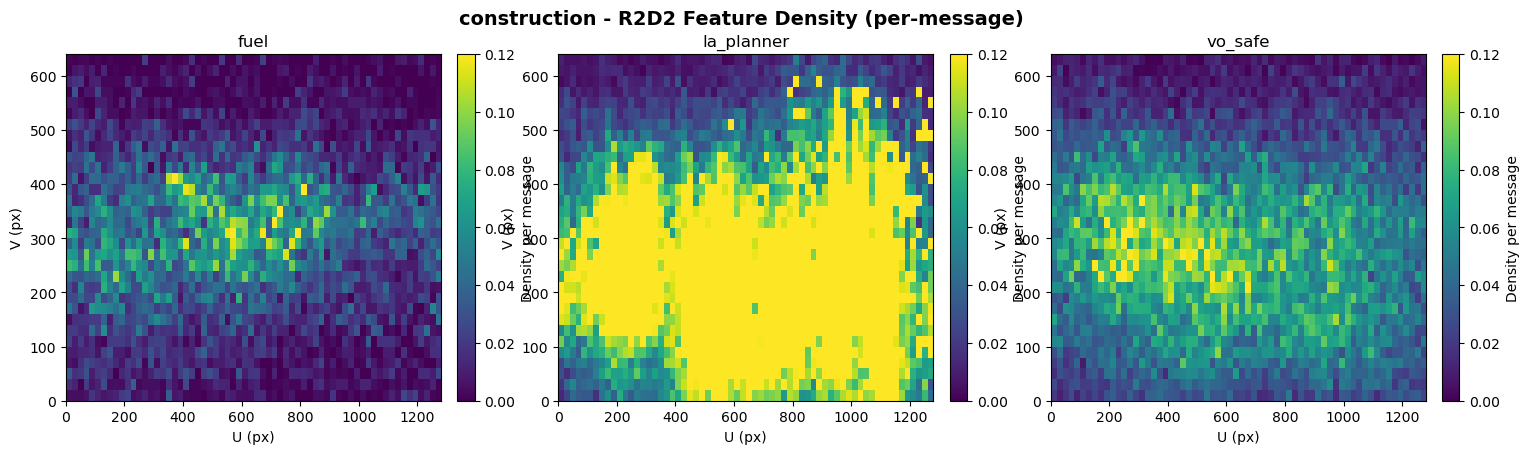


=== Heatmap Compare: construction - OV ===


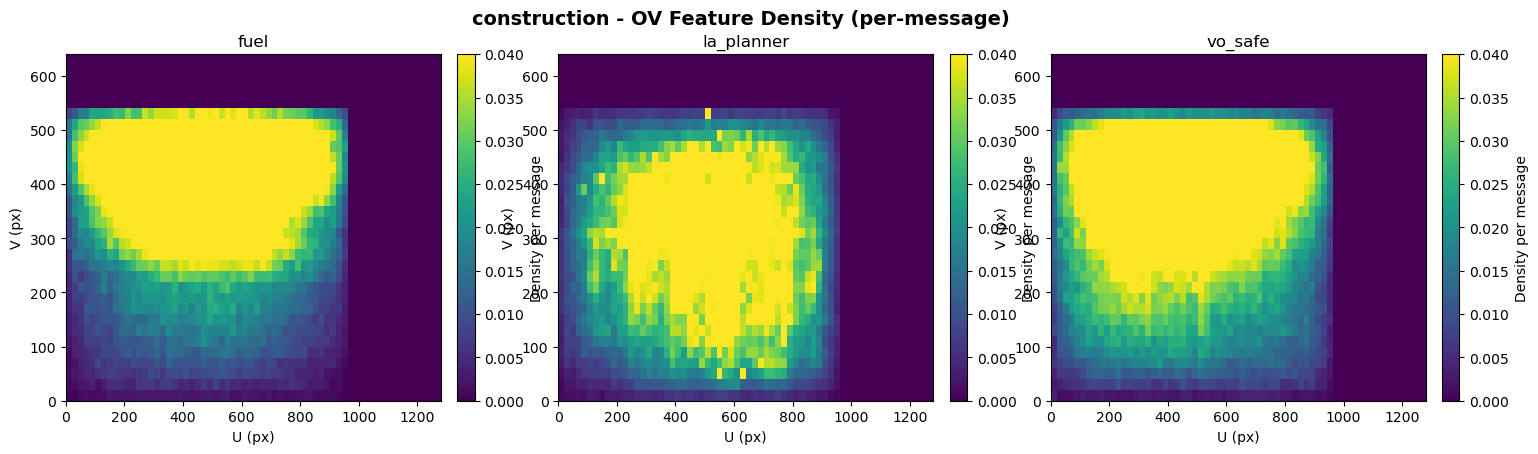


=== Curve: construction Position Error vs Normalized Exploration Rate ===


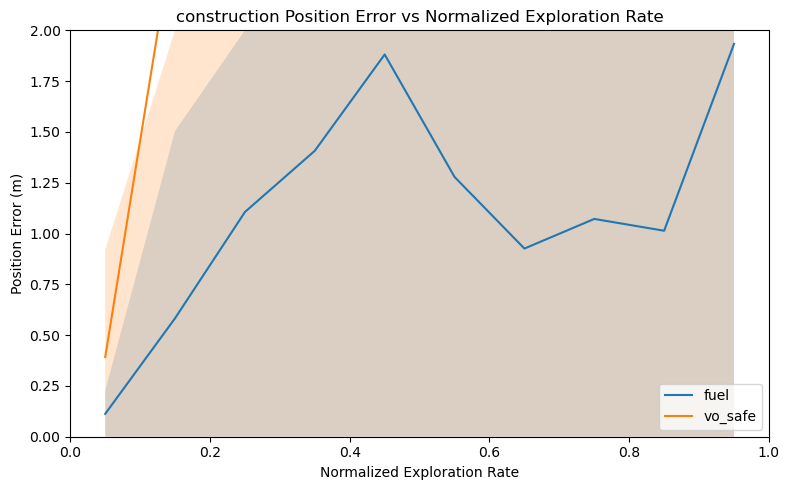


=== Density Time Series: construction - R2D2 ===


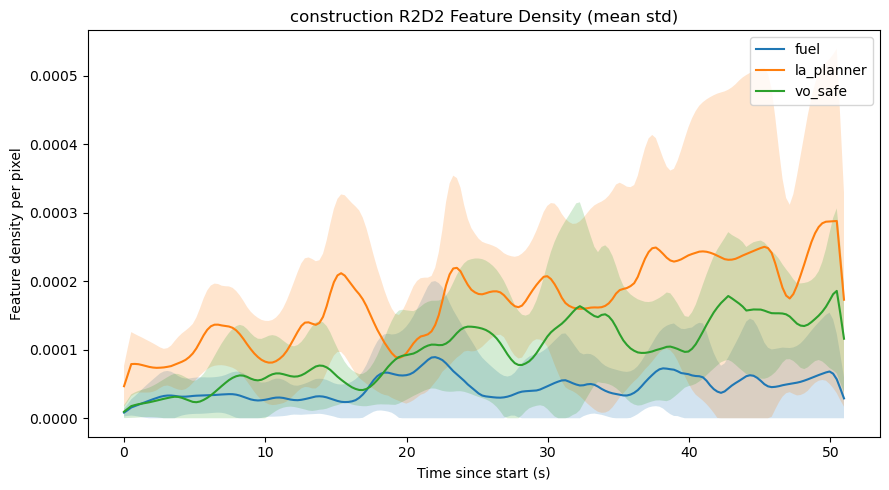

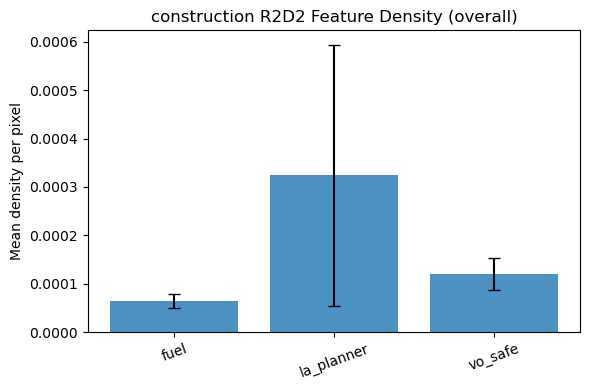


=== Density Time Series: construction - OV ===


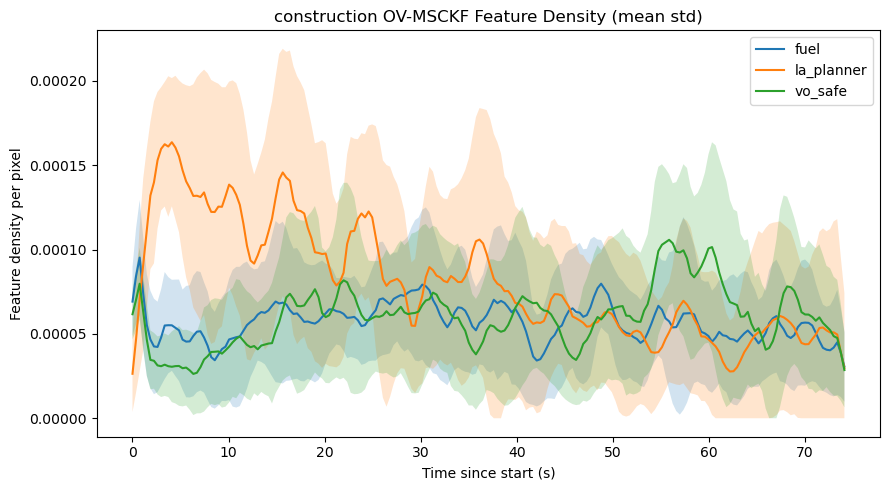

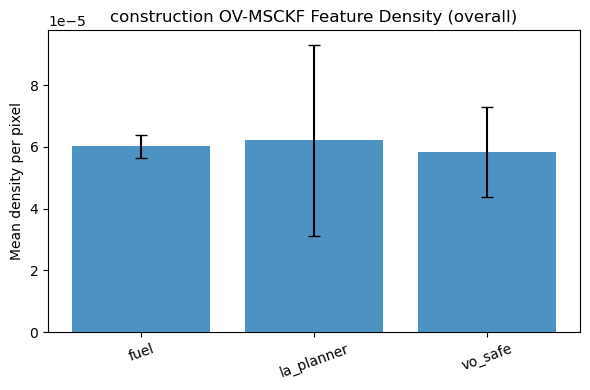


--- Success Exploration Rate ---
map                  method              n mean_success_exploration_rate_norm std       
construction         fuel                9 0.693815                         0.377599  
construction         la_planner          6 0.261099                         0.107697  
construction         vo_safe             9 0.636826                         0.392247  

--- Success Exploration Time (s) ---
map                  method            n_success mean_time_s      std       
construction         fuel                      8 70.827625        8.211134  
construction         la_planner                0 nan              nan       
construction         vo_safe                   5 135.852600       11.861898 

--- Features per Timestamp ---
map                  method             n_bags ov_mean      ov_std       r2d2_weight_mean     r2d2_weight_std   
construction         fuel                    9 49.277150    3.028845     50.600833            11.221036         
construction

In [11]:
# 在 Notebook 内显示结果（不写入任何文件）

# 显示热力图对比
for map_name, method_map in heatmaps_r2d2.items():
    print(f"\n=== Heatmap Compare: {map_name} - R2D2 ===")
    combined_compare_figure(map_name + ' - R2D2', method_map, tuple((0, 0.12)), out_path=None)
    print(f"\n=== Heatmap Compare: {map_name} - OV ===")
    combined_compare_figure(map_name + ' - OV', heatmaps_ov[map_name], tuple((0, 0.04)), out_path=None)

# 显示误差-探索率曲线
for map_name, method_pairs in curve_points.items():
    print(f"\n=== Curve: {map_name} Position Error vs Normalized Exploration Rate ===")
    plot_error_vs_exploration_compare(map_name, method_pairs, args.curve_bins, 2, out_path=None)

# 新增：R2D2/OV 特征密度随时间对比
for map_name in sorted(series_density_r2d2.keys() | series_density_ov.keys()):
    if map_name in series_density_r2d2:
        print(f"\n=== Density Time Series: {map_name} - R2D2 ===")
        plot_feature_density_time_series(map_name, series_density_r2d2[map_name], 'R2D2 Feature Density', out_path=None, smooth=True)
    if map_name in series_density_ov:
        print(f"\n=== Density Time Series: {map_name} - OV ===")
        plot_feature_density_time_series(map_name, series_density_ov[map_name], 'OV-MSCKF Feature Density', out_path=None, smooth=True)

# 以文本形式打印统计表
print("\n--- Success Exploration Rate ---")
header_rate = 'mean_success_exploration_rate_norm' if args.normalize_success_rate else 'mean_success_exploration_rate'
print(f"{'map':<20} {'method':<16} {'n':>4} {header_rate:<32} {'std':<10}")
for row in rows_success_rate:
    m, d, n, mean_v, std_v = row
    print(f"{m:<20} {d:<16} {n:>4d} {mean_v:<32.6f} {std_v:<10.6f}")

print("\n--- Success Exploration Time (s) ---")
print(f"{'map':<20} {'method':<16} {'n_success':>10} {'mean_time_s':<16} {'std':<10}")
for row in rows_success_time:
    m, d, n_succ, mean_t, std_t = row
    n_succ = int(n_succ)
    print(f"{m:<20} {d:<16} {n_succ:>10d} {mean_t:<16.6f} {std_t:<10.6f}")

print("\n--- Features per Timestamp ---")
print(f"{'map':<20} {'method':<16} {'n_bags':>8} {'ov_mean':<12} {'ov_std':<12} {'r2d2_weight_mean':<20} {'r2d2_weight_std':<18}")
for row in rows_feat_per_ts:
    m, d, n_bags, ov_mean, ov_std, r2d2_mean, r2d2_std = row
    n_bags = int(n_bags)
    print(f"{m:<20} {d:<16} {n_bags:>8d} {ov_mean:<12.6f} {ov_std:<12.6f} {r2d2_mean:<20.6f} {r2d2_std:<18.6f}")

# 打印分组信息
print("\n--- Groups (map__method -> #bags) ---")
for (m, d), bags in sorted(groups.items()):
    print(f"{m}__{d}: {len(bags)}")

print("\nDone. 所有图表已在 Notebook 中展示，统计表已打印。")


In [ ]:
# 批量运行不同阈值的后处理与展示（不会重读 rosbag）

def run_post_analysis_once(threshold: float):
    print(f"\n\n=== Running post analysis with threshold={threshold:.1f} ===")
    args.threshold = float(threshold)

    # 初始化容器
    heatmaps_r2d2 = defaultdict(dict)
    heatmaps_ov = defaultdict(dict)
    curve_points = defaultdict(lambda: defaultdict(list))
    series_density_r2d2 = defaultdict(lambda: defaultdict(list))
    series_density_ov = defaultdict(lambda: defaultdict(list))
    rows_success_rate = []
    rows_success_time = []
    rows_feat_per_ts = []

    # 构建处理结果（从原始缓存）
    proc_group_results: Dict[Tuple[str, str], List[dict]] = defaultdict(list)
    only_maps_set = set(args.only_maps) if args.only_maps else None
    for (map_name, method), raw_list in sorted(dict_raw_group_data.items()):
        if only_maps_set is not None and map_name not in only_maps_set:
            continue
        results = []
        for raw in raw_list:
            res = postprocess_single_bag_from_raw(raw, args)
            if res is None:
                continue
            results.append(res)
        proc_group_results[(map_name, method)] = results

    # 构建 success ref
    success_ref_map = build_success_ref_map(proc_group_results, normalize_by_method={'la_planner': 'fuel'})

    # 统计聚合
    for (map_name, method), results in sorted(proc_group_results.items()):
        success_ref = success_ref_map[(map_name, method)]
        success_rates = []
        success_times = []
        ov_means = []
        r2d2_weight_means = []
        sum_r2d2 = None
        sum_ov = None
        total_r2d2_msgs = 0
        total_ov_msgs = 0
        r2d2_edges = None
        ov_edges = None
        method_curve_pairs = []
        r2d2_all_t, r2d2_all_d = [], []
        ov_all_t, ov_all_d = [], []

        for res in results:
            if 'ov_mean_per_msg' in res and not np.isnan(res['ov_mean_per_msg']):
                ov_means.append(res['ov_mean_per_msg'])
            if 'r2d2_weight_mean_per_msg' in res and not np.isnan(res['r2d2_weight_mean_per_msg']):
                r2d2_weight_means.append(res['r2d2_weight_mean_per_msg'])

            sum_r2d2 = accumulate_heatmap(sum_r2d2, res['r2d2_heat'], res.get('r2d2_msg_count', 0))
            sum_ov = accumulate_heatmap(sum_ov, res['ov_heat'], res.get('ov_msg_count', 0))
            if r2d2_edges is None:
                r2d2_edges = res['r2d2_edges']
            if ov_edges is None:
                ov_edges = res['ov_edges']
            total_r2d2_msgs += int(res.get('r2d2_msg_count', 0))
            total_ov_msgs += int(res.get('ov_msg_count', 0))

            raw_success_rate = float(res.get('success_exploration_rate_raw', np.nan))
            if np.isfinite(raw_success_rate):
                rate_val = raw_success_rate
                if args.normalize_success_rate:
                    rate_val = float(np.clip(rate_val / success_ref, 0.0, 1.0))
                success_rates.append(rate_val)

            t_arr = np.asarray(res.get('raw_exploration_times', []), dtype=float)
            r_arr = np.asarray(res.get('raw_exploration_rates', []), dtype=float)
            if t_arr.size > 0 and r_arr.size > 0 and np.isfinite(success_ref) and success_ref > 0:
                cutoff = float(success_ref * float(args.completion_percent))
                idxs = np.where(r_arr >= cutoff)[0]
                if idxs.size > 0:
                    t_comp = float(t_arr[int(idxs[0])] - t_arr[0])
                    if np.isfinite(t_comp) and t_comp >= 0:
                        success_times.append(t_comp)

            if method != 'la_planner':
                if 'raw_exp_rate_on_error_t' in res and 'curve_y' in res:
                    try:
                        norm_rate_arr = np.clip(np.asarray(res['raw_exp_rate_on_error_t'], dtype=float) / success_ref, 0.0, 1.0)
                    except Exception:
                        norm_rate_arr = np.asarray(res['curve_x'])
                    pos_err_arr = np.asarray(res['curve_y'])
                    fallback_val = float(np.clip(raw_success_rate / success_ref, 0.0, 1.0)) if np.isfinite(raw_success_rate) else float('nan')
                    if norm_rate_arr is not None and norm_rate_arr.size > 0 and pos_err_arr.size > 0:
                        method_curve_pairs.append((pos_err_arr, norm_rate_arr, fallback_val))

            if 'r2d2_msg_times' in res and 'r2d2_density_per_msg' in res and len(res['r2d2_msg_times']) > 0:
                r2d2_all_t.append(np.asarray(res['r2d2_msg_times'], dtype=float))
                r2d2_all_d.append(np.asarray(res['r2d2_density_per_msg'], dtype=float))
            if 'ov_msg_times' in res and 'ov_density_per_msg' in res and len(res['ov_msg_times']) > 0:
                ov_all_t.append(np.asarray(res['ov_msg_times'], dtype=float))
                ov_all_d.append(np.asarray(res['ov_density_per_msg'], dtype=float))

        avg_r2d2 = average_heatmap(sum_r2d2, total_r2d2_msgs, args.image_width, args.image_height, args.bin_size)
        avg_ov = average_heatmap(sum_ov, total_ov_msgs, args.image_width, args.image_height, args.bin_size)
        if r2d2_edges is None:
            r2d2_edges = default_edges(args.image_width, args.image_height, args.bin_size)
        if ov_edges is None:
            ov_edges = default_edges(args.image_width, args.image_height, args.bin_size)

        heatmaps_r2d2[map_name][method] = (avg_r2d2, r2d2_edges[0], r2d2_edges[1])
        heatmaps_ov[map_name][method] = (avg_ov, ov_edges[0], ov_edges[1])
        if method_curve_pairs:
            curve_points[map_name][method] = method_curve_pairs

        if success_rates:
            rows_success_rate.append([map_name, method, len(success_rates), float(np.mean(success_rates)), float(np.std(success_rates))])
        else:
            rows_success_rate.append([map_name, method, 0, float('nan'), float('nan')])

        if success_times:
            rows_success_time.append([map_name, method, len(success_times), float(np.mean(success_times)), float(np.std(success_times))])
        else:
            rows_success_time.append([map_name, method, 0, float('nan'), float('nan')])

        if ov_means or r2d2_weight_means:
            n_feat = max(len(ov_means), len(r2d2_weight_means))
            rows_feat_per_ts.append([
                map_name, method,
                n_feat,
                float(np.mean(ov_means)) if ov_means else float('nan'),
                float(np.std(ov_means)) if ov_means else float('nan'),
                float(np.mean(r2d2_weight_means)) if r2d2_weight_means else float('nan'),
                float(np.std(r2d2_weight_means)) if r2d2_weight_means else float('nan'),
            ])
        else:
            rows_feat_per_ts.append([map_name, method, 0, float('nan'), float('nan'), float('nan'), float('nan')])

        if r2d2_all_t:
            series_density_r2d2[map_name][method] = list(zip(r2d2_all_t, r2d2_all_d))
        if ov_all_t:
            series_density_ov[map_name][method] = list(zip(ov_all_t, ov_all_d))

    # 绘图
    for map_name, method_map in heatmaps_r2d2.items():
        print(f"\n=== [thr={threshold:.1f}] Heatmap Compare: {map_name} - R2D2 ===")
        combined_compare_figure(map_name + ' - R2D2', method_map, tuple((0, 0.12)), out_path=None)
        print(f"\n=== [thr={threshold:.1f}] Heatmap Compare: {map_name} - OV ===")
        combined_compare_figure(map_name + ' - OV', heatmaps_ov[map_name], tuple((0, 0.04)), out_path=None)

    for map_name, method_pairs in curve_points.items():
        print(f"\n=== [thr={threshold:.1f}] Curve: {map_name} Position Error vs Normalized Exploration Rate ===")
        plot_error_vs_exploration_compare(map_name, method_pairs, args.curve_bins, 2, out_path=None)

    for map_name in sorted(series_density_r2d2.keys() | series_density_ov.keys()):
        if map_name in series_density_r2d2:
            print(f"\n=== [thr={threshold:.1f}] Density Time Series: {map_name} - R2D2 ===")
            plot_feature_density_time_series(map_name, series_density_r2d2[map_name], 'R2D2 Feature Density', out_path=None, smooth=True)
        if map_name in series_density_ov:
            print(f"\n=== [thr={threshold:.1f}] Density Time Series: {map_name} - OV ===")
            plot_feature_density_time_series(map_name, series_density_ov[map_name], 'OV-MSCKF Feature Density', out_path=None, smooth=True)

    # 表格
    print("\n--- Success Exploration Rate ---")
    header_rate = 'mean_success_exploration_rate_norm' if args.normalize_success_rate else 'mean_success_exploration_rate'
    print(f"{'map':<20} {'method':<16} {'n':>4} {header_rate:<32} {'std':<10}")
    for row in rows_success_rate:
        m, d, n, mean_v, std_v = row
        print(f"{m:<20} {d:<16} {n:>4d} {mean_v:<32.6f} {std_v:<10.6f}")

    print("\n--- Success Exploration Time (s) ---")
    print(f"{'map':<20} {'method':<16} {'n_success':>10} {'mean_time_s':<16} {'std':<10}")
    for row in rows_success_time:
        m, d, n_succ, mean_t, std_t = row
        n_succ = int(n_succ)
        print(f"{m:<20} {d:<16} {n_succ:>10d} {mean_t:<16.6f} {std_t:<10.6f}")

    print("\n--- Features per Timestamp ---")
    print(f"{'map':<20} {'method':<16} {'n_bags':>8} {'ov_mean':<12} {'ov_std':<12} {'r2d2_weight_mean':<20} {'r2d2_weight_std':<18}")
    for row in rows_feat_per_ts:
        m, d, n_bags, ov_mean, ov_std, r2d2_mean, r2d2_std = row
        n_bags = int(n_bags)
        print(f"{m:<20} {d:<16} {n_bags:>8d} {ov_mean:<12.6f} {ov_std:<12.6f} {r2d2_mean:<20.6f} {r2d2_std:<18.6f}")

# 循环运行三组阈值
for thr in [1.0, 2.0, 3.0]:
    run_post_analysis_once(thr)





=== Running post analysis with threshold=1.0 ===
Common time range: 345.67 to 420.55 seconds
Speed-based time range: 345.67 to 419.14 seconds
Adjusted time range: 345.67 to 420.55 seconds
First common odometry timestamp: 345.76 seconds
Initial position offset: (0.059, 0.005, 1.032) m
Initial orientation offset: 89.33°
Calculated 924 error measurements after alignment
Extracted 1925 R2D2 feature points
Extracted 41612 OV-MSCKF loop feature points
Common time range: 345.24 to 429.14 seconds
Speed-based time range: 345.24 to 428.04 seconds
Adjusted time range: 345.24 to 429.14 seconds
First common odometry timestamp: 345.34 seconds
Initial position offset: (-0.029, 0.100, 0.961) m
Initial orientation offset: 87.99°
Calculated 1024 error measurements after alignment
Extracted 3435 R2D2 feature points
Extracted 48451 OV-MSCKF loop feature points
Common time range: 345.42 to 439.79 seconds
Speed-based time range: 345.42 to 438.58 seconds
Adjusted time range: 345.42 to 439.79 seconds
First 

In [16]:
# 仅计算不同阈值下的 Success Exploration Rate（不绘图、不计算其他统计）

def postprocess_success_only_from_raw(raw_data: tuple, args):
    (
        exploration_data, gt_odom_data, vins_odom_data,
        _r2d2_pointcloud_data, _ov_msckf_pointcloud_data,
    ) = raw_data
    if not all([exploration_data, gt_odom_data, vins_odom_data]):
        return None

    (
        exploration_times, exploration_rates, error_times, position_errors, _orientation_errors,
        _gt_t, _gt_x, _gt_y, _gt_z,
        _vins_t, _vins_x, _vins_y, _vins_z,
    ) = synchronize_and_calculate_errors(exploration_data, gt_odom_data, vins_odom_data)
    if exploration_times is None:
        return None

    total_time = float(exploration_times[-1] - exploration_times[0]) if len(exploration_times) > 1 else 0.0
    exp_rate_on_error_t = interpolate_exploration_rate(exploration_times, exploration_rates, error_times)

    failure_idx = None
    failure_time = None
    if len(position_errors) > 0:
        mask = position_errors >= args.threshold
        if np.any(mask):
            failure_idx = int(np.argmax(mask))
            failure_time = float(error_times[failure_idx])

    if failure_idx is not None:
        val = float(exp_rate_on_error_t[failure_idx]) if not np.isnan(exp_rate_on_error_t[failure_idx]) else float('nan')
        success_exploration_rate = val
    else:
        success_exploration_rate = float(exploration_rates[-1]) if len(exploration_rates) > 0 else float('nan')

    success_run = (failure_idx is None) and (total_time < args.success_time_limit)
    last_exploration_rate = float(exploration_rates[-1]) if len(exploration_rates) > 0 else float('nan')

    return {
        'success_exploration_rate_raw': success_exploration_rate,
        'success_run': success_run,
        'last_exploration_rate': last_exploration_rate,
    }


def run_success_rate_once(threshold: float):
    print(f"\n\n=== Success Exploration Rate @ threshold={threshold:.1f} ===")
    args.threshold = float(threshold)

    # 逐组后处理（仅 success 相关）
    proc_group_results: Dict[Tuple[str, str], List[dict]] = defaultdict(list)
    only_maps_set = set(args.only_maps) if args.only_maps else None
    for (map_name, method), raw_list in sorted(dict_raw_group_data.items()):
        if only_maps_set is not None and map_name not in only_maps_set:
            continue
        results = []
        for raw in raw_list:
            res = postprocess_success_only_from_raw(raw, args)
            if res is None:
                continue
            results.append(res)
        proc_group_results[(map_name, method)] = results

    # 构建成功参考并统计 Success Exploration Rate（可归一化）
    success_ref_map = build_success_ref_map(proc_group_results, normalize_by_method={'la_planner': 'fuel'})

    header_rate = 'mean_success_exploration_rate_norm' if args.normalize_success_rate else 'mean_success_exploration_rate'
    print(f"{'map':<20} {'method':<16} {'n':>4} {header_rate:<32} {'std':<10}")

    for (map_name, method), results in sorted(proc_group_results.items()):
        if not results:
            print(f"{map_name:<20} {method:<16} {0:>4d} {float('nan'):<32.6f} {float('nan'):<10.6f}")
            continue
        rates = []
        success_ref = success_ref_map[(map_name, method)]
        for res in results:
            raw_rate = float(res.get('success_exploration_rate_raw', np.nan))
            if np.isfinite(raw_rate):
                val = raw_rate
                if args.normalize_success_rate and np.isfinite(success_ref) and success_ref > 0:
                    val = float(np.clip(val / success_ref, 0.0, 1.0))
                rates.append(val)
        if rates:
            mean_v = float(np.mean(rates))
            std_v = float(np.std(rates))
            print(f"{map_name:<20} {method:<16} {len(rates):>4d} {mean_v:<32.6f} {std_v:<10.6f}")
        else:
            print(f"{map_name:<20} {method:<16} {0:>4d} {float('nan'):<32.6f} {float('nan'):<10.6f}")

# 运行三组阈值，输出三张 Success Exploration Rate 表
for thr in [1.0, 2.0, 3.0]:
    run_success_rate_once(thr)





=== Success Exploration Rate @ threshold=1.0 ===
map                  method              n mean_success_exploration_rate_norm std       
construction         fuel                9 0.693815                         0.377599  
construction         la_planner          6 0.261099                         0.107697  
construction         vo_safe             9 0.636826                         0.392247  


=== Success Exploration Rate @ threshold=2.0 ===
map                  method              n mean_success_exploration_rate_norm std       
construction         fuel                9 0.863207                         0.257076  
construction         la_planner          6 0.261501                         0.107616  
construction         vo_safe             9 0.730354                         0.338503  


=== Success Exploration Rate @ threshold=3.0 ===
map                  method              n mean_success_exploration_rate_norm std       
construction         fuel                9 0.866248       